In [1]:
import pandas as pd
import numpy as np
import torch
import warnings
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, TQDMProgressBar
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer # Critical for scaling
from pytorch_forecasting.metrics import CrossEntropy

warnings.filterwarnings("ignore", message="X does not have valid feature names")
print("Environment Ready.")

W0420 02:48:16.620000 48448 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Environment Ready.


In [2]:

df = pd.read_csv('data/MSFT_processed_data.csv')
df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)
df['time_idx'] = df.index
df['symbol'] = "MSFT"


sentiment_map = {'positive': 1, 'neutral': 0, 'mixed': 0, 'negative': -1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_map).fillna(0)
df['Decayed_Sentiment'] = df['Sentiment_Score'] / np.log1p(df['News_Age_Minutes'] + 1)
df['Close_to_SMA50'] = df['Close'] / df['SMA_50']
df['Close_to_Kalman'] = df['Close'] / df['kalman_close']


df['Relative_Volume'] = df['Volume'] / df['Volume'].rolling(window=20).mean()
df['Relative_Transactions'] = df['Transactions'] / df['Transactions'].rolling(window=20).mean()

minutes_since_midnight = df['Stock_Timestamp'].dt.hour * 60 + df['Stock_Timestamp'].dt.minute
df['Time_Sin'] = np.sin(2 * np.pi * minutes_since_midnight / 1440)
df['Time_Cos'] = np.cos(2 * np.pi * minutes_since_midnight / 1440)

df['Target'] = (df['Close'] > df['Close'].shift(1)).astype(int)

df = df.dropna().reset_index(drop=True)
df['time_idx'] = df.index 
print(f"Data Prepared. Total Rows: {len(df)}")

Data Prepared. Total Rows: 90838


In [3]:
max_prediction_length = 1 
max_encoder_length = 60   

total_len = len(df)
train_cutoff = df["time_idx"].iloc[int(total_len * 0.7)]
val_cutoff = df["time_idx"].iloc[int(total_len * 0.9)]

training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= train_cutoff],
    time_idx="time_idx",
    target="Target",
    group_ids=["symbol"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["symbol"],
    time_varying_known_reals=["Time_Sin", "Time_Cos"],
    time_varying_unknown_reals=[
        "Close", "RSI_14", "kalman_diff", "Close_to_SMA50", "Relative_Volume", 
        "Relative_Transactions", "Decayed_Sentiment"
    ],
    target_normalizer=None, 

    scalers={
        "Close": GroupNormalizer(),
        "Relative_Volume": GroupNormalizer(),
        "Relative_Transactions": GroupNormalizer()
    },
    add_relative_time_idx=True,
    add_target_scales=False,
    add_encoder_length=True,
)

# 2. Validation and Test Sets (predict=False for full metrics)
validation = TimeSeriesDataSet.from_dataset(training, df[lambda x: (x.time_idx > train_cutoff) & (x.time_idx <= val_cutoff)], predict=False)
testing = TimeSeriesDataSet.from_dataset(training, df[lambda x: x.time_idx > val_cutoff], predict=False)

train_dataloader = training.to_dataloader(train=True, batch_size=128, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)
test_dataloader = testing.to_dataloader(train=False, batch_size=128, num_workers=0)

print(f"Splits: Train={len(training)}, Val={len(validation)}, Test={len(testing)}")

Splits: Train=63527, Val=18108, Test=9023


In [4]:
from torchmetrics import Accuracy
acc = Accuracy(task="multiclass", num_classes=2)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=32,     
    attention_head_size=4,
    dropout=0.1,
    loss=CrossEntropy(),
    logging_metrics=torch.nn.ModuleList([acc]),
    output_size=2 
)

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [5]:
class LitProgressBar(TQDMProgressBar):
    def get_metrics(self, trainer, model):
        items = super().get_metrics(trainer, model)
        items.pop("v_num", None)
        return items

trainer = Trainer(
    max_epochs=20,
    accelerator="cpu",
    devices=1,
    callbacks=[LitProgressBar(refresh_rate=50), EarlyStopping(monitor="val_loss", patience=5)],
    gradient_clip_val=0.1,
)

trainer.fit(tft, train_dataloader, val_dataloader)
best_model_path = trainer.checkpoint_callback.best_model_path

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compa

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ CrossEntropy                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    176 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 10.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     66 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 67.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 67.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 371                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litm

--- Final Statistical Performance (10% Test Set) ---
              precision    recall  f1-score   support

        Down       0.85      0.78      0.81      4570
          Up       0.79      0.85      0.82      4453

    accuracy                           0.81      9023
   macro avg       0.82      0.81      0.81      9023
weighted avg       0.82      0.81      0.81      9023



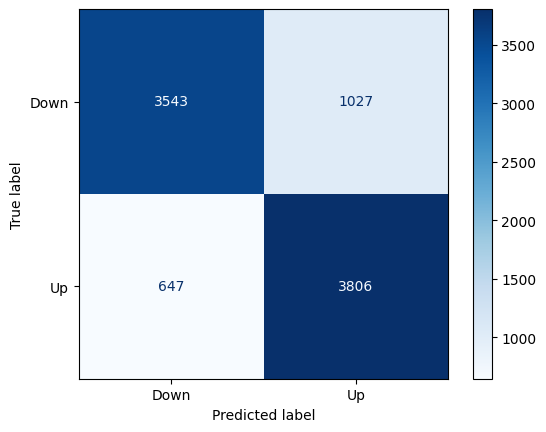

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
raw_predictions = best_tft.predict(test_dataloader, mode="raw", return_y=True, return_x=True)

y_pred = raw_predictions.output.prediction.argmax(dim=-1).flatten().cpu().numpy()
y_true = raw_predictions.y[0].flatten().cpu().numpy()

print("--- Final Statistical Performance (10% Test Set) ---")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=['Down', 'Up'], zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['Down', 'Up'], cmap='Blues')
plt.show()

--- Compounding Simulation Results ---
Initial Capital: $10,000.00
Final Balance:   $52,410.42
Total Return:    424.10%


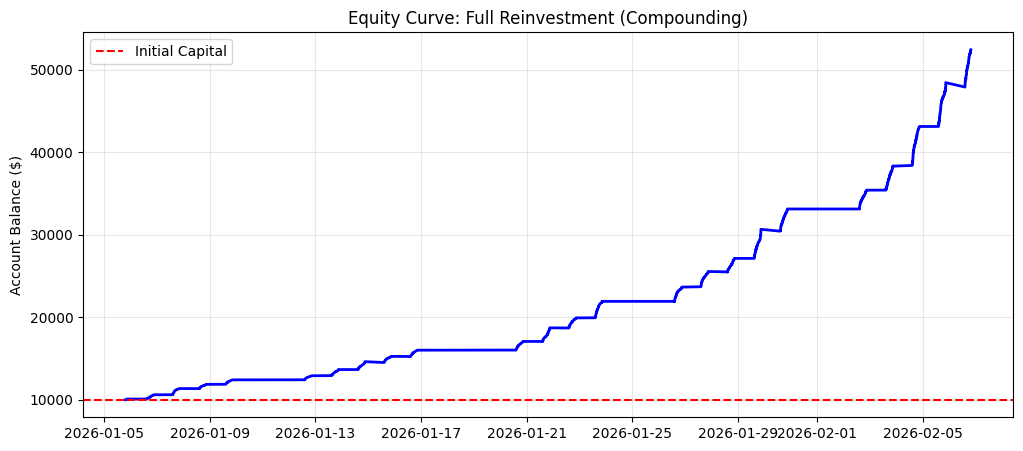

In [7]:
initial_capital = 10000.0
current_balance = initial_capital
cost_per_share = 0.009


time_indices = raw_predictions.x['decoder_time_idx'].flatten().cpu().numpy()
sim_df = df.iloc[time_indices].copy()
sim_df['Signal'] = y_pred


sim_df['Entry_Price'] = sim_df['Open']
sim_df['Exit_Price'] = sim_df['Open'].shift(-1)

balances = []
for i in range(len(sim_df)):
    row = sim_df.iloc[i]

    if row['Signal'] == 1 and not np.isnan(row['Exit_Price']):
        num_shares = current_balance // row['Entry_Price']
        if num_shares > 0:

            trade_profit = (num_shares * (row['Exit_Price'] - row['Entry_Price'])) - (num_shares * cost_per_share)
            current_balance += trade_profit
    balances.append(current_balance)

sim_df['Portfolio_Value'] = balances

print(f"--- Compounding Simulation Results ---")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Balance:   ${current_balance:,.2f}")
print(f"Total Return:    {((current_balance - initial_capital)/initial_capital)*100:,.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(sim_df['Stock_Timestamp'], sim_df['Portfolio_Value'], color='blue', linewidth=2)
plt.axhline(initial_capital, color='red', linestyle='--', label='Initial Capital')
plt.title("Equity Curve: Full Reinvestment (Compounding)")
plt.ylabel("Account Balance ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()